
# STAT 426B: Homework 1

- UID: 206547205
- Name: Hochan Son
- Email: hochanson@g.ucla.edu


## Problem 1: Single-Layer MLP & Binary Classification

Consider a subset of the MNIST data set. The original data set is a widely used database of handwritten digits (0–9) used to train and test image classifiers. It consists of 70,000 grayscale images, 28 ×28 pixels each, pre-processed to ensure consistency. For this homework, the digits 3, 4, 5, and 9 have been selected and pre-split into training,
validation, and test sets.

### Part (a): Classifying Digits 3 vs 5
Train a single-layer MLP (one hidden layer) to classify the digits 3 and 5 using a binary
cross-entropy loss function.
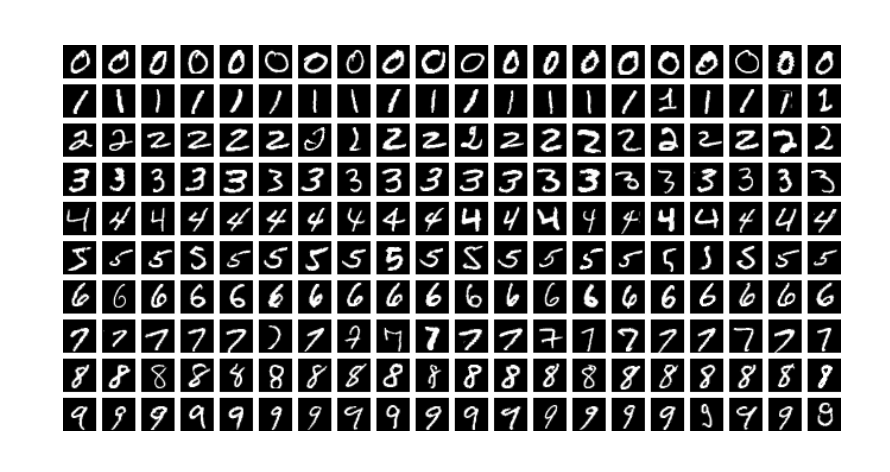
1. Grid Search: Tune the model using the validation set. Grid search over the following
hyperparameters:
- Mini-batch size s ∈{64, 128, 256}
- Hidden layer dimension h ∈{64, 128, 256}

3. Training: Fix the number of epochs to 30.

4. Evaluation: Select the best configuration based on validation performance. For this
best model:
- Plot the Training and Validation Loss vs. Epochs.
- Evaluate on the Test Data Set: Plot the ROC curve and calculate the AUC.

In [ ]:
# install prerequisite packages
!pip install torch==2.9.1 torchvision --quiet
!pip install scikit-learn matplotlib --quiet

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score


: 

In [ ]:
import numpy as np
import csv
import matplotlib.pyplot as plt

def _load_mnist_dataset(path=None):
    with open(path, 'r') as csv_file:
        csvreader = csv.reader(csv_file)
        # Skip the header row
        next(csvreader, None)
        for row in csvreader:
            yield row

def plot_data2(path):      
    images = []
    labels = []
    
    # Load first 64 images for 8x8 grid
    for data in _load_mnist_dataset(path):
        if len(images) >= 64:
            break
            
        label = data[0]
        # Pixel data is normalized (0-1) in this dataset based on previous inspection
        pixels = np.array(data[1:], dtype='float32').reshape((28, 28))
        
        images.append(pixels)
        labels.append(label)

    # created 8x8 grid
    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    fig.suptitle('MNIST 8x8 Grid', fontsize=16)
    
    # Flatten axes array for easy iteration
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < len(images):
            ax.imshow(images[i], cmap='gray')
            ax.set_title(f"Label: {labels[i]}", fontsize=8)
            ax.axis('off')
        else:
            ax.axis('off') # Hide unused subplots
            
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("===============sample_mnist_test==============")
    plot_data2('./mnist_test.csv')
    print("===============sample_mnist_train=============")
    plot_data2('./mnist_train.csv')
    print("===============sample_mnist_val===============")
    plot_data2('./mnist_val.csv')
    print("=====================end=====================")

: 

In [4]:
# def generate_data(N=10000, p=100, noise_level=0.15, correlation=0.5):
#     """
#     Generates synthetic binary classification data.

#     Args:
#         N: Sample size
#         p: Number of features
#         noise_level: Percentage of labels to flip (c)
#         correlation: Target average correlation between features
#     """
#     # 1. Generate Covariance Matrix for correlated features
#     # Diagonal is 1, off-diagonal is 'correlation'
#     cov_matrix = np.full((p, p), correlation)
#     np.fill_diagonal(cov_matrix, 1.0)

#     # Generate X ~ N(0, Sigma)
#     mean = np.zeros(p)
#     X = np.random.multivariate_normal(mean, cov_matrix, size=N)

#     # 2. Generate True Weights (beta)
#     # Random weights from normal distribution
#     beta = np.random.normal(0, 1, size=p)

#     # 3. Calculate Probabilities via Logistic Sigmoid
#     logits = X @ beta
#     probs = 1 / (1 + np.exp(-logits))

#     # 4. Generate Initial Labels y
#     y = np.random.binomial(1, probs)

#     # 5. Apply Label Noise (Flip c% of labels)
#     n_flip = int(noise_level * N)
#     flip_indices = np.random.choice(np.arange(N), size=n_flip, replace=False)
#     y[flip_indices] = 1 - y[flip_indices] # Flip 0 to 1, 1 to 0

#     # Convert to PyTorch tensors
#     X_tensor = torch.tensor(X, dtype=torch.float32)
#     y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Shape (N, 1)

#     return X_tensor, y_tensor

# # Generate the full dataset
# X, y = generate_data(N=10000, p=100, noise_level=0.15)
# print(f"Data Generated: X shape {X.shape}, y shape {y.shape}")

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
import pandas as pd # Used for a nice output table

class SingleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SingleMLP, self).__init__()
        # Input Layer -> Hidden Layer
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        # Hidden Layer -> Output (Scalar)
        self.output = nn.Linear(hidden_dim, 1) #Bindary output
        # Activation function
        self.activation = nn.ReLU()
    
    @staticmethod
    def _load_filter_data(self, path, name="Dataset"):
        """
        Loads the dataset from a CSV file, filters for digits 3 and 5, and prepares tensors.

        Args:
            path (str): The file path to the CSV dataset.
            name (str, optional): A name for the dataset (e.g., "Train", "Test") for logging purposes. Defaults to "Dataset".

        Returns:
            tuple: A tuple containing two torch.Tensors:
                - X (torch.Tensor): Feature matrix of shape (N, 784) with float32 type.
                - y (torch.Tensor): Label vector of shape (N, 1) with float32 type, where 3->0 and 5->1.

        Raises:
            ValueError: If the filtered dataset is empty (i.e., no digits 3 or 5 found).
        """
        print(f"Loading {name} from {path}...")
        df = pd.read_csv(path)
    
        label_col = df.columns[0]
        
        # Digits 3 and 5
        target_digits = [3, 5]
        
        df_filtered = df[df[label_col].isin(target_digits)].copy()

        if df_filtered.empty:
            raise ValueError(f"Error: No data found for digits 3 and 5 in {path}. Please check if the file contains these labels in the first column ('{label_col}').")
            
        # Map 3 -> 0, 5 -> 1
        y = df_filtered[label_col].apply(lambda x: 0 if x == 3 else 1).values
        
        # Features. Drop label column.
        X = df_filtered.drop(columns=[label_col]).values
        
        # Ensure float32
        X = X.astype(np.float32)
        y = y.astype(np.float32)
        
        print(f"  Shape after filtering: {X.shape}")
        
        return torch.tensor(X), torch.tensor(y).unsqueeze(1)

    def forward(self, x):
        x = self.activation(self.layer1(x))
        # We return logits (raw scores) because we use BCEWithLogitsLoss
        return self.output(x)

print("Model class defined successfully.")

Model class defined successfully.


In [11]:
def run_experiment(config, train_ds, val_ds, test_ds):
    """
    Trains a model with specific hyperparameters and returns final metrics.
    """
    # Unpack hyperparameter configuration dictionary
    i_dim = config['input_dim']
    h_dim = config['hidden_dim']
    lr = config['lr']
    bs = config['batch_size']
    epochs = config['epochs']

    print ("i_dim:{}\n,h_dim:{}\n,lr:{}\n,bs:{}\n,epochs:{}\n".format(i_dim, h_dim, lr, bs, epochs))

    # Helper to ensure input is a Dataset
    def ensure_dataset(data_input, name_suffix=""):
        if isinstance(data_input, str):
            # It's a path, load it
            X, y = SingleMLP._load_filter_data(data_input, name_suffix)
            return TensorDataset(X, y)
        return data_input

    # Prepare Datasets (Load if they are paths)
    train_ds = ensure_dataset(train_ds, "Train")
    val_ds = ensure_dataset(val_ds, "Val")
    test_ds = ensure_dataset(test_ds, "Test")
    
    # Create Local DataLoaders specific to this batch size (bs)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False)
    # added test_loader
    test_loader = DataLoader(test_ds, batch_size=bs, shuffle=False)


    # Initialize Model & Optimizer
    model = SingleMLP(input_dim=i_dim, hidden_dim=h_dim)
    criterion = nn.BCEWithLogitsLoss() # More stable than Sigmoid + BCELoss
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_loss_history = []
    
    print("\nStarting Training...")
    # --- Training Phase ---
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()           # Clear gradients
            outputs = model(inputs)         # Forward pass
            loss = criterion(outputs, labels)
            loss.backward()                 # Backward pass
            optimizer.step()                # Update weights
            running_train_loss += loss.item() * inputs.size(0)
            
        avg_train_loss = running_train_loss / len(train_ds)
        train_loss_history.append(avg_train_loss)
        
    # --- Evaluation Phase (Validation Set) ---
    model.eval()
    total_val_loss = 0
    running_val_loss = 0
    val_loss_history = []

    with torch.no_grad(): # Disable gradient calculation for speed
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)  # calculate loss
            running_val_loss += loss.item() * inputs.size(0) # running validation loss
    avg_val_loss = running_val_loss / len(val_ds)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    # --- Test Phase (metrics) ---
    # Validating on Val set for Grid Search selection
    model.eval()
    val_targets = []
    val_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            # Apply Sigmoid to get probability (0-1) for AUC calc
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            val_targets.extend(labels.numpy())
            val_preds.extend(probs.numpy())

    all_preds = np.array(val_preds)
    all_targets = np.array(val_targets)
    
    avg_final_val_loss = val_loss_history[-1]
    val_auc = roc_auc_score(val_targets, val_preds)

    return avg_val_loss, val_auc

print("Experiment runner defined.")

Experiment runner defined.


In [12]:
# List of dictionaries, each representing one experiment
experiments = [
    # 1. Baseline
    {'input_dim':784, 'hidden_dim': 32,  'lr': 0.01, 'batch_size': 64,  'epochs': 30},
    # 2. Wider Network + Higher Learning Rate
    {'input_dim':784, 'hidden_dim': 128, 'lr': 0.1,  'batch_size': 64,  'epochs': 30},
    # 3. Smaller Batch Size (More noisy updates, often better generalization)
    {'input_dim':784, 'hidden_dim': 128, 'lr': 0.01, 'batch_size': 32,  'epochs': 30},
    # 4. Large Batch + Wide Network (Approximates full gradient descent)
    {'input_dim':784, 'hidden_dim': 512, 'lr': 0.1,  'batch_size': 256, 'epochs': 30},
    # 5. Very High Learning Rate (Risk of instability)
    {'input_dim':784, 'hidden_dim': 32,  'lr': 0.5,  'batch_size': 64,  'epochs': 30},
]

print(f"Grid defined with {len(experiments)} configurations.")

Grid defined with 5 configurations.


In [14]:
results = []
print(f"Starting Grid Search on {len(experiments)} configurations...\n")

# Paths
train_path = './mnist_train.csv'
val_path = './mnist_val.csv'
test_path = './mnist_test.csv'

for i, conf in enumerate(experiments):
    # Run the experiment
    print ("{},{}".format(i, conf))
    loss, auc = run_experiment(conf, train_path, val_path, test_path)

    # Store results
    res = conf.copy()
    res['val_loss'] = loss
    res['val_auc'] = auc
    results.append(res)

    print(f"Exp {i+1}: Hidden={conf['hidden_dim']}, LR={conf['lr']}, Batch={conf['batch_size']} -> Val Loss: {loss:.4f}, AUC: {auc:.4f}")

# Display Leaderboard
df_results = pd.DataFrame(results)
print("shape:{}".format(df_results.shape))
print("\n" + "="*40)
print(" FINAL LEADERBOARD (Sorted by Best AUC)")
print("="*40)
# Sort values so the best model is at the top
print(df_results.sort_values(by='val_auc', ascending=False).to_string(index=False))

Starting Grid Search on 5 configurations...

0,{'input_dim': 784, 'hidden_dim': 32, 'lr': 0.01, 'batch_size': 64, 'epochs': 30}
i_dim:784
,h_dim:32
,lr:0.01
,bs:64
,epochs:30

Loading Dataset from Train...


FileNotFoundError: [Errno 2] No such file or directory: 'Train'

Retraining Best Model: Hidden=32, LR=0.01, Batch=64...


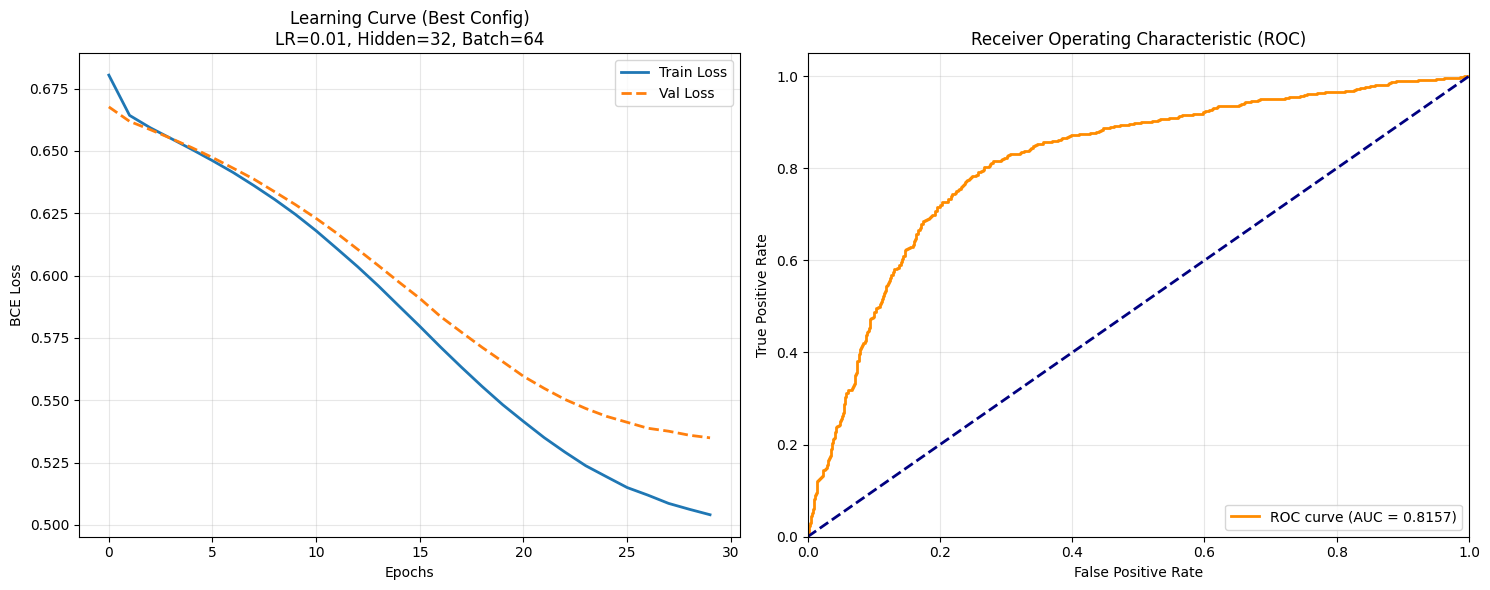

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Retrieve Best Configuration
# ==========================================
# We grab the top row from the sorted dataframe 'df_results'
best_row = df_results.sort_values(by='val_auc', ascending=False).iloc[0]

h_dim = int(best_row['hidden_dim'])
lr = best_row['lr']
bs = int(best_row['batch_size'])
epochs = int(best_row['epochs'])

print(f"Retraining Best Model: Hidden={h_dim}, LR={lr}, Batch={bs}...")

# 2. Retrain to Capture History
# ==========================================
# Re-create loaders for the winning batch size
t_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
v_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

# Re-init model
model = SingleMLP(input_dim=100, hidden_dim=h_dim)
optimizer = optim.SGD(model.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()

# Lists to store per-epoch history
history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    # --- Training Step ---
    model.train()
    running_loss = 0
    for inputs, labels in t_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    history['train_loss'].append(running_loss / len(train_dataset))

    # --- Validation Step ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in v_loader:
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item() * inputs.size(0)
    history['val_loss'].append(val_loss / len(val_dataset))

# 3. Calculate ROC Curve Data
# ==========================================
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in v_loader:
        outputs = model(inputs)
        probs = torch.sigmoid(outputs) # Convert logits to probability
        y_true.extend(labels.numpy())
        y_scores.extend(probs.numpy())

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 4. Plotting
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Loss Curves
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
ax1.set_title(f'Learning Curve (Best Config)\nLR={lr}, Hidden={h_dim}, Batch={bs}')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: ROC Curve
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver Operating Characteristic (ROC)')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()